STOCK PRICE SIMULATION - GEOMETRIC BROWNIAN MOTION
Initial Price (S0): $100
Drift (μ): 8.00%
Volatility (σ): 25.00%
Time Horizon: 1.0 year
Time Steps: 252 (daily)
Number of Paths: 10


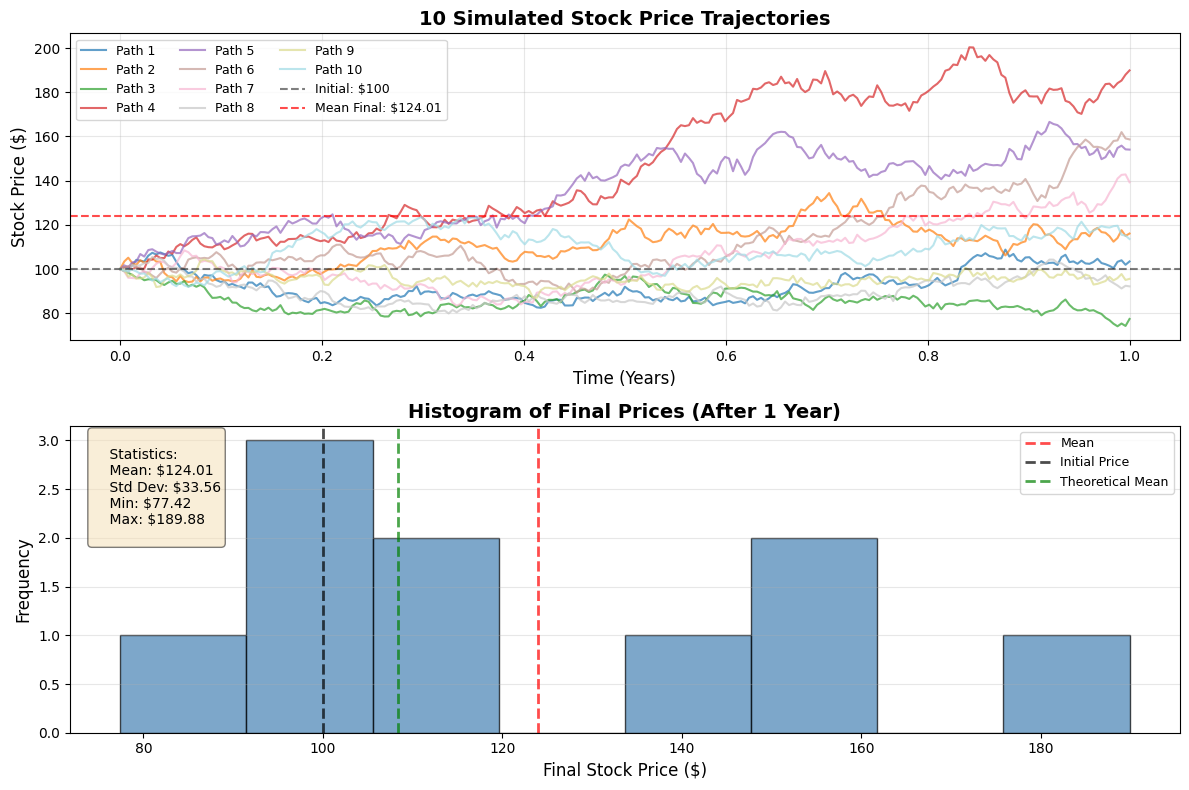


SIMULATION RESULTS:
----------------------------------------
Final Prices: [103.44 116.07  77.42 189.88 154.04 158.65 139.28  92.17  95.56 113.6 ]

Summary Statistics:
  Average Final Price: $124.01
  Theoretical Expected: $108.33
  Standard Deviation: $33.56
  Coefficient of Variation: 27.06%

Return Analysis:
  Average Return: 24.01%
  Return Volatility: 33.56%
  Positive Returns: 7/10 paths
  Maximum Gain: 89.88%
  Maximum Loss: -22.58%

Risk Metrics:
  95% Value at Risk (VaR): 15.95% (maximum loss with 95% confidence)
  Range of Outcomes: $77.42 to $189.88



In [ ]:
"""
Stock Price Simulation using GBM

"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# PART 1: GENERATE STOCK PRICE PATHS USING GBM
# ============================================================================

def simulate_gbm(S0, mu, sigma, T, N, num_paths):
    """
    Simulate Geometric Brownian Motion paths for stock prices

    Parameters:
    S0: Initial stock price
    mu: Expected annual return (drift)
    sigma: Annual volatility
    T: Time horizon in years
    N: Number of time steps
    num_paths: Number of paths to simulate
    """

    # Time discretization
    dt = T / N
    t = np.linspace(0, T, N+1)

    # Initialize price matrix
    S = np.zeros((num_paths, N+1))
    S[:, 0] = S0

    # Generate random normal increments
    Z = np.random.normal(0, 1, (num_paths, N))

    # Simulate paths
    for i in range(N):
        # GBM formula from computational finance course
        S[:, i+1] = S[:, i] * np.exp(
            (mu - 0.5 * sigma**2) * dt +
            sigma * np.sqrt(dt) * Z[:, i]
        )

    return t, S

# ============================================================================
# PART 2: MAIN SIMULATION AND VISUALIZATION
# ============================================================================

def main():
    # Simulation parameters
    np.random.seed(42)  # For reproducibility
    S0 = 100
    mu = 0.08      # 8% expected return
    sigma = 0.25   # 25% volatility
    T = 1.0        # 1 year
    N = 252        # Trading days
    num_paths = 10

    print("=" * 60)
    print("STOCK PRICE SIMULATION - GEOMETRIC BROWNIAN MOTION")
    print("=" * 60)
    print(f"Initial Price (S0): ${S0}")
    print(f"Drift (μ): {mu:.2%}")
    print(f"Volatility (σ): {sigma:.2%}")
    print(f"Time Horizon: {T} year")
    print(f"Time Steps: {N} (daily)")
    print(f"Number of Paths: {num_paths}")
    print("=" * 60)

    # Generate paths
    t, S = simulate_gbm(S0, mu, sigma, T, N, num_paths)
    final_prices = S[:, -1]

    # ========================================================================
    # PLOT 1: PRICE TRAJECTORIES
    # ========================================================================
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)

    colors = plt.cm.tab20(np.linspace(0, 1, num_paths))


    for i in range(num_paths):
        # Using matplotlib.pyplot.plot
        plt.plot(t, S[i, :],
                color=colors[i],
                linewidth=1.5,
                alpha=0.7,
                label=f'Path {i+1}')

    plt.xlabel('Time (Years)', fontsize=12)
    plt.ylabel('Stock Price ($)', fontsize=12)
    plt.title('10 Simulated Stock Price Trajectories',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', ncol=2, fontsize=9)

    # Add reference lines
    plt.axhline(y=S0, color='black', linestyle='--', alpha=0.5,
                label=f'Initial: ${S0}')

    # Calculate and display statistics
    mean_final = np.mean(final_prices)
    plt.axhline(y=mean_final, color='red', linestyle='--', alpha=0.7,
                label=f'Mean Final: ${mean_final:.2f}')
    plt.legend(loc='upper left', ncol=3, fontsize=9)

    # ========================================================================
    # PLOT 2: HISTOGRAM OF FINAL PRICES
    # ========================================================================
    plt.subplot(2, 1, 2)

    # Create histogram
    n_bins = min(8, len(final_prices))  # Adjust bins based on data
    counts, bins, patches = plt.hist(final_prices,
                                     bins=n_bins,
                                     edgecolor='black',
                                     alpha=0.7,
                                     color='steelblue',
                                     density=False)

    plt.xlabel('Final Stock Price ($)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Histogram of Final Prices (After 1 Year)',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')

    # Add statistical information
    stats_text = f"""
    Statistics:
    Mean: ${np.mean(final_prices):.2f}
    Std Dev: ${np.std(final_prices):.2f}
    Min: ${np.min(final_prices):.2f}
    Max: ${np.max(final_prices):.2f}
    """

    plt.text(0.02, 0.98, stats_text,
             transform=plt.gca().transAxes,
             verticalalignment='top',
             fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Add vertical lines for key values
    plt.axvline(x=mean_final, color='red', linestyle='--',
                linewidth=2, alpha=0.7, label='Mean')
    plt.axvline(x=S0, color='black', linestyle='--',
                linewidth=2, alpha=0.7, label='Initial Price')

    # Theoretical log-normal mean
    theoretical_mean = S0 * np.exp(mu * T)
    plt.axvline(x=theoretical_mean, color='green', linestyle='--',
                linewidth=2, alpha=0.7, label='Theoretical Mean')

    plt.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.savefig('stock_simulation_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ========================================================================
    # ADDITIONAL ANALYSIS
    # ========================================================================
    print("\nSIMULATION RESULTS:")
    print("-" * 40)

    # Calculate returns
    returns = (final_prices - S0) / S0
    positive_returns = np.sum(returns > 0)

    print(f"Final Prices: {final_prices.round(2)}")
    print(f"\nSummary Statistics:")
    print(f"  Average Final Price: ${np.mean(final_prices):.2f}")
    print(f"  Theoretical Expected: ${theoretical_mean:.2f}")
    print(f"  Standard Deviation: ${np.std(final_prices):.2f}")
    print(f"  Coefficient of Variation: {np.std(final_prices)/np.mean(final_prices):.2%}")
    print(f"\nReturn Analysis:")
    print(f"  Average Return: {np.mean(returns):.2%}")
    print(f"  Return Volatility: {np.std(returns):.2%}")
    print(f"  Positive Returns: {positive_returns}/{num_paths} paths")
    print(f"  Maximum Gain: {np.max(returns):.2%}")
    print(f"  Maximum Loss: {np.min(returns):.2%}")

    # Risk metrics
    var_95 = np.percentile(returns, 5)  # 5th percentile = 95% VaR
    print(f"\nRisk Metrics:")
    print(f"  95% Value at Risk (VaR): {abs(var_95):.2%} (maximum loss with 95% confidence)")
    print(f"  Range of Outcomes: ${np.min(final_prices):.2f} to ${np.max(final_prices):.2f}")

    print("\n" + "=" * 60)

if __name__ == "__main__":
    main()